In [2]:
import os 
import pandas as pd

In [3]:
df = pd.read_csv("arxiv_dataset_all_info.csv")

In [5]:
df_target = df[["id", "novelty"]].groupby("id").mean() # unfortunately, one ID is there 3 times, todo: fix in data

In [8]:
df_results = []

for filename in os.listdir("results/"):
    filepath = os.path.join("results", filename)
    if filepath.endswith("_result.csv"):
        df = pd.read_csv(filepath, index_col=0).groupby("id").mean()
        df.columns = [f"{filename[:-len("_result.csv")]}_score"]
        df_results.append(df)

In [12]:
df_result = df_target
for df in df_results:
    df_result = df_result.join(df, how="left")

In [13]:
df_result

,novelty,falcon3:7b_score,di_values_10years_score,jean-luc:tiger-gemma-9b-v3:fp16_score,specter2_IF_score,gpt-oss:latest_score,mistral:7b_score,takenusername:gpt-4o-precise:latest_score,specter2_LOF_score
id,,,,,,,,,
http://arxiv.org/abs/0704.0484v4,0.512065,3.0,NaN,2.0,0.432290,1.0,6.5,7.0,1.124532
http://arxiv.org/abs/0704.0560v2,0.466193,7.0,NaN,6.0,0.500976,6.0,8.5,8.0,1.070234
http://arxiv.org/abs/0704.0982v3,0.471383,8.0,NaN,6.0,0.436370,7.0,8.5,8.5,1.065333
http://arxiv.org/abs/0704.1054v1,0.341872,7.0,NaN,7.0,0.453460,5.0,8.5,8.5,1.002413
http://arxiv.org/abs/0704.1942v7,0.300996,4.0,NaN,2.0,0.436983,2.0,6.5,3.5,1.007443
...,...,...,...,...,...,...,...,...,...
http://arxiv.org/abs/quant-ph/9602006v1,0.395234,7.0,NaN,7.0,0.456346,2.0,8.5,8.0,1.119166
http://arxiv.org/abs/quant-ph/9612021v1,0.430788,5.0,NaN,2.0,0.453381,4.0,6.5,8.5,1.038798
http://arxiv.org/abs/quant-ph/9701032v1,0.443576,7.0,NaN,6.0,0.445138,4.0,8.5,8.0,1.047166


array([[<Axes: title={'center': 'novelty'}>,
        <Axes: title={'center': 'falcon3:7b_score'}>,
        <Axes: title={'center': 'di_values_10years_score'}>],
       [<Axes: title={'center': 'jean-luc:tiger-gemma-9b-v3:fp16_score'}>,
        <Axes: title={'center': 'specter2_IF_score'}>,
        <Axes: title={'center': 'gpt-oss:latest_score'}>],
       [<Axes: title={'center': 'mistral:7b_score'}>,
        <Axes: title={'center': 'takenusername:gpt-4o-precise:latest_score'}>,
        <Axes: title={'center': 'specter2_LOF_score'}>]], dtype=object)

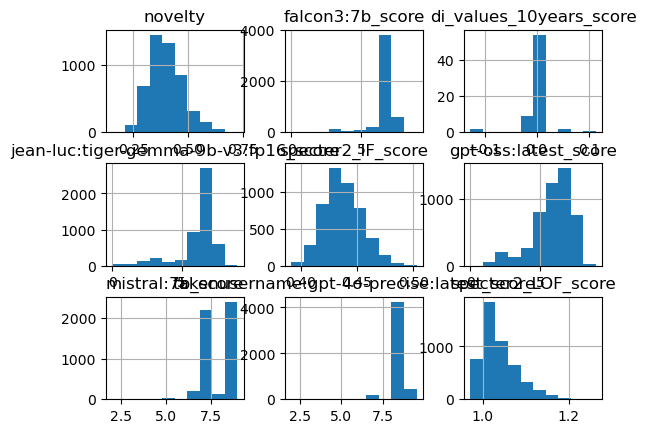

In [14]:
df_result.hist()

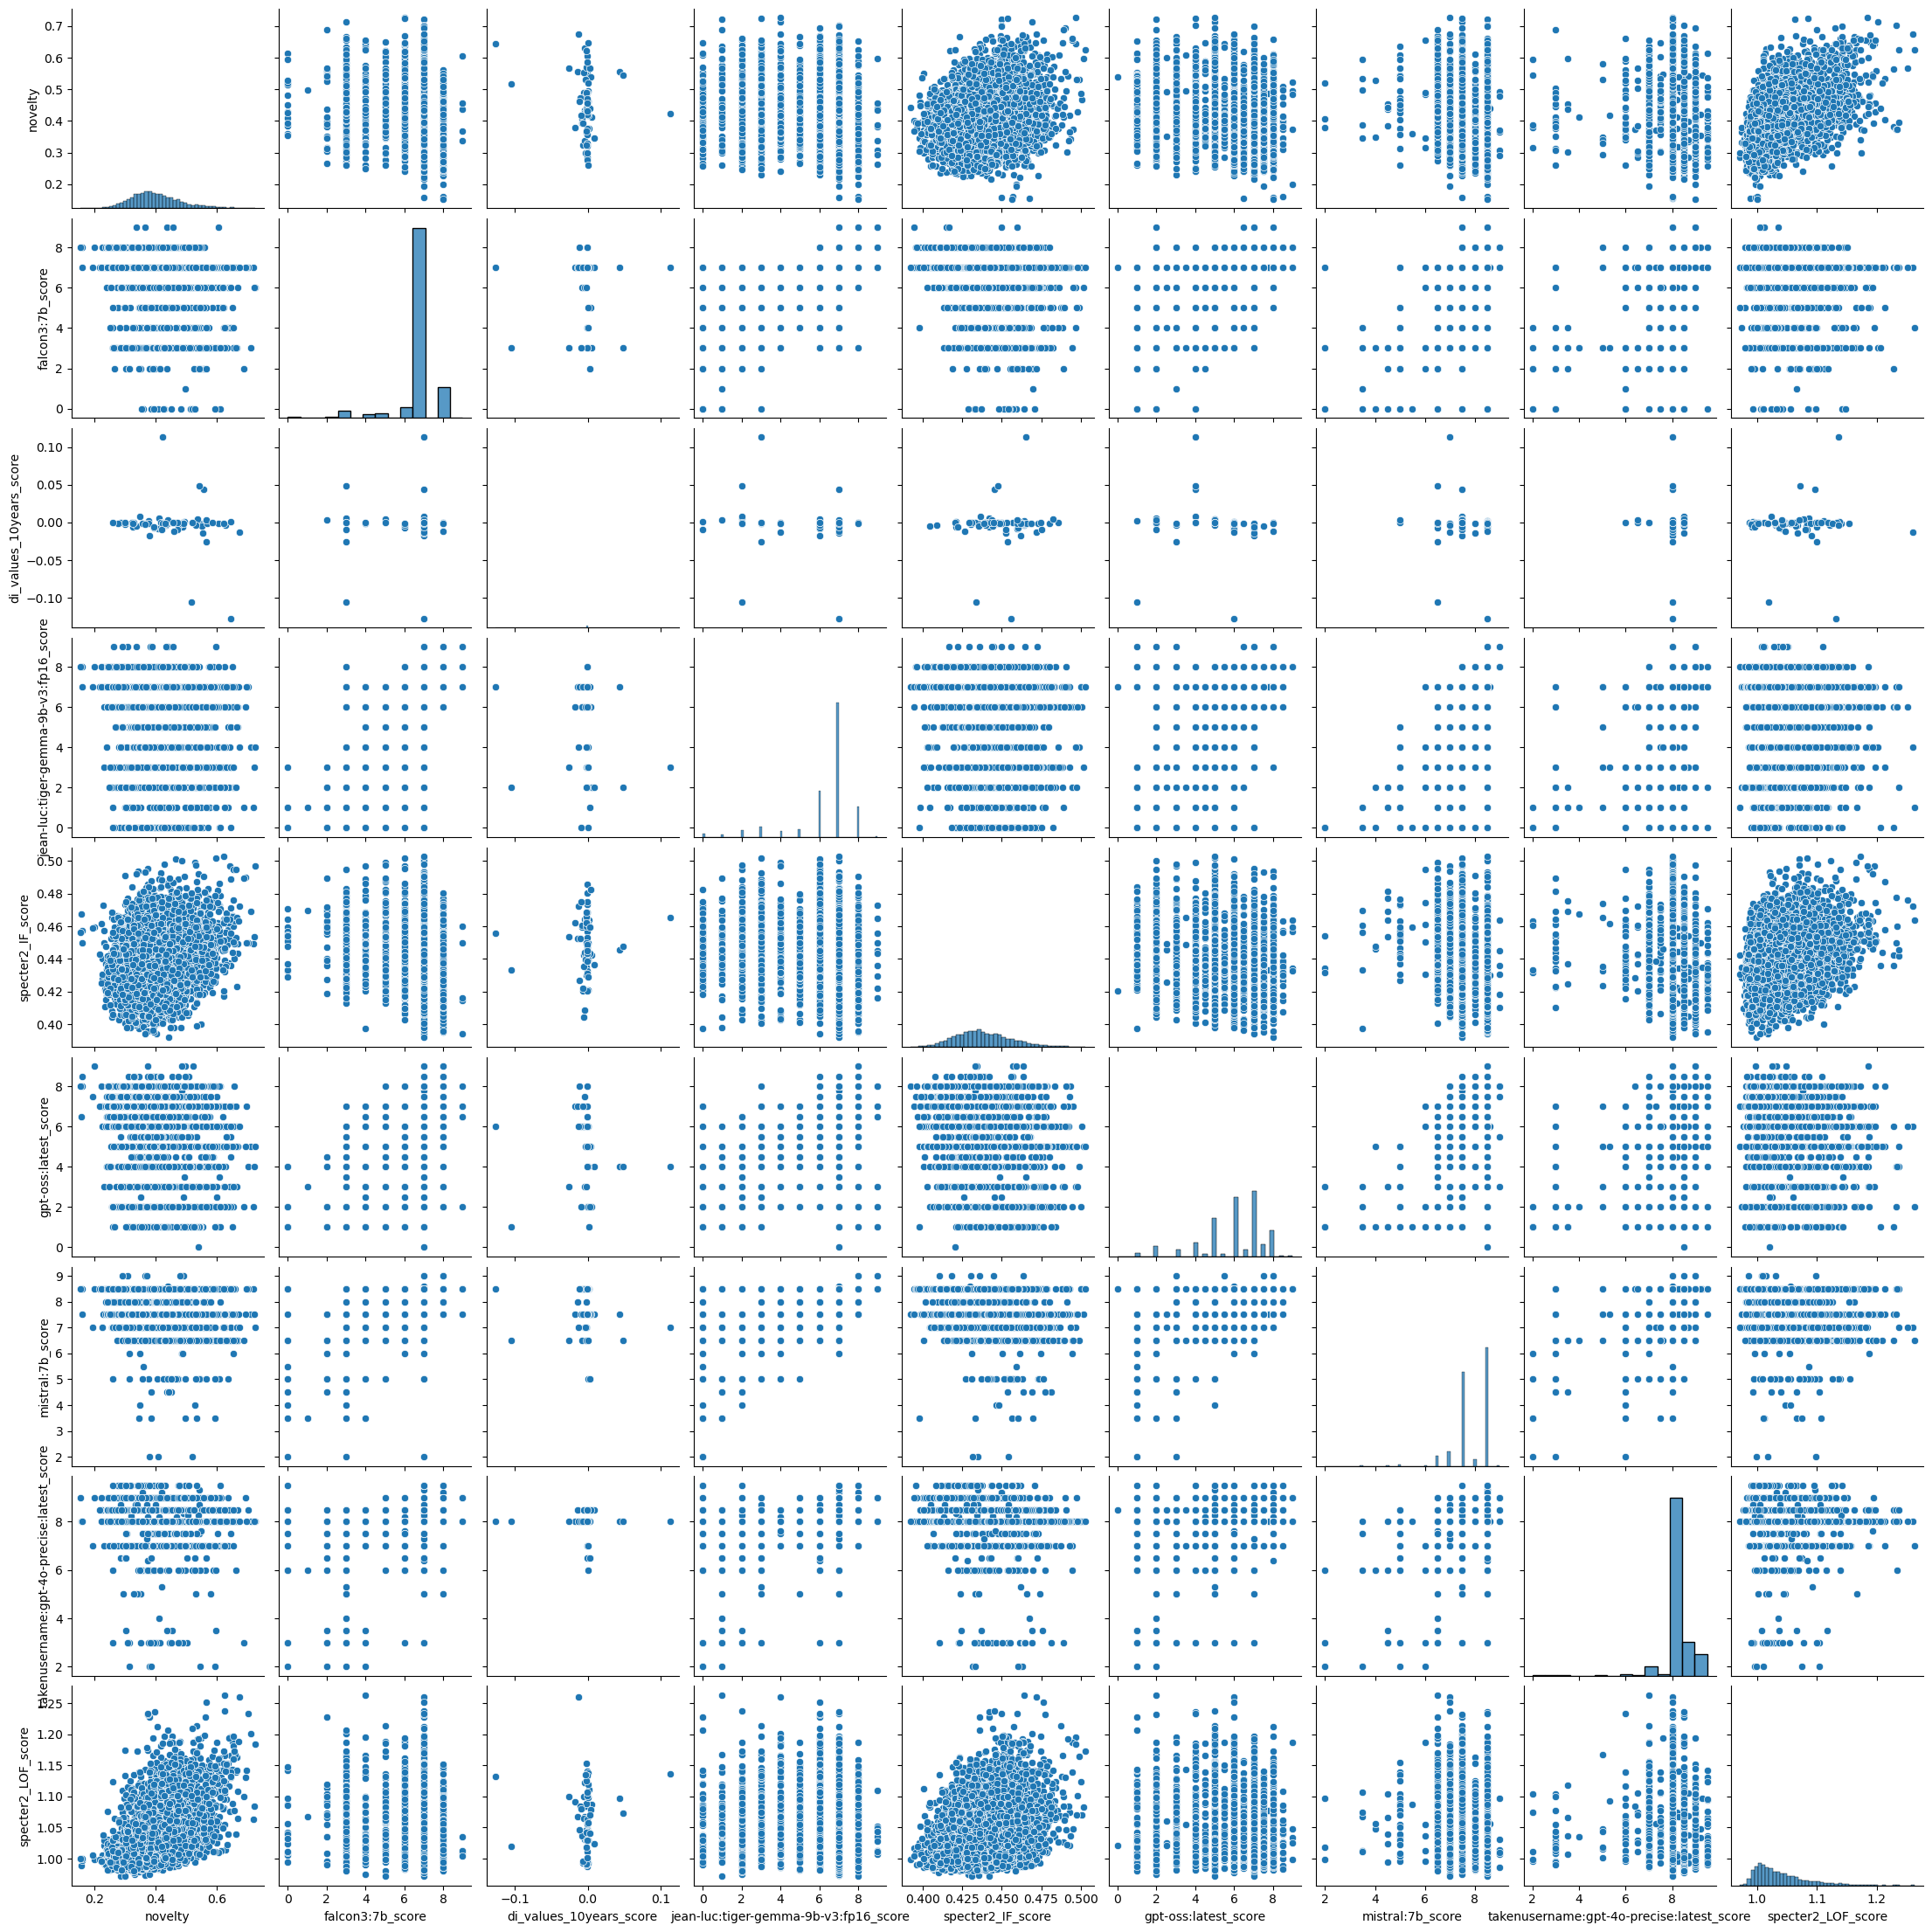

In [16]:
import seaborn as sns
sns.pairplot(df_result)

In [17]:
df_result.corr()

,novelty,falcon3:7b_score,di_values_10years_score,jean-luc:tiger-gemma-9b-v3:fp16_score,specter2_IF_score,gpt-oss:latest_score,mistral:7b_score,takenusername:gpt-4o-precise:latest_score,specter2_LOF_score
novelty,1.000000,-0.183767,-0.173558,-0.209898,0.245651,-0.160862,-0.203325,-0.081636,0.548909
falcon3:7b_score,-0.183767,1.000000,0.076798,0.696791,-0.218661,0.554099,0.507590,0.380289,-0.158704
di_values_10years_score,-0.173558,0.076798,1.000000,-0.075615,0.072734,-0.026712,-0.083839,-0.012114,0.035769
jean-luc:tiger-gemma-9b-v3:fp16_score,-0.209898,0.696791,-0.075615,1.000000,-0.230851,0.677162,0.565324,0.352288,-0.158098
specter2_IF_score,0.245651,-0.218661,0.072734,-0.230851,1.000000,-0.201611,-0.221681,-0.116950,0.342302
gpt-oss:latest_score,-0.160862,0.554099,-0.026712,0.677162,-0.201611,1.000000,0.423136,0.282571,-0.112888
mistral:7b_score,-0.203325,0.507590,-0.083839,0.565324,-0.221681,0.423136,1.000000,0.360095,-0.198141
takenusername:gpt-4o-precise:latest_score,-0.081636,0.380289,-0.012114,0.352288,-0.116950,0.282571,0.360095,1.000000,-0.066275
specter2_LOF_score,0.548909,-0.158704,0.035769,-0.158098,0.342302,-0.112888,-0.198141,-0.066275,1.000000


In [18]:
df_result.corr(method="spearman")

,novelty,falcon3:7b_score,di_values_10years_score,jean-luc:tiger-gemma-9b-v3:fp16_score,specter2_IF_score,gpt-oss:latest_score,mistral:7b_score,takenusername:gpt-4o-precise:latest_score,specter2_LOF_score
novelty,1.000000,-0.181552,-0.086557,-0.202921,0.218527,-0.145527,-0.186368,-0.077239,0.544457
falcon3:7b_score,-0.181552,1.000000,-0.102893,0.630917,-0.202679,0.487448,0.469218,0.279806,-0.166818
di_values_10years_score,-0.086557,-0.102893,1.000000,-0.149429,-0.004123,-0.417968,-0.054455,0.024368,0.000763
jean-luc:tiger-gemma-9b-v3:fp16_score,-0.202921,0.630917,-0.149429,1.000000,-0.232036,0.617401,0.585419,0.256749,-0.179924
specter2_IF_score,0.218527,-0.202679,-0.004123,-0.232036,1.000000,-0.185558,-0.209909,-0.088365,0.308715
gpt-oss:latest_score,-0.145527,0.487448,-0.417968,0.617401,-0.185558,1.000000,0.396209,0.188016,-0.112416
mistral:7b_score,-0.186368,0.469218,-0.054455,0.585419,-0.209909,0.396209,1.000000,0.233337,-0.196841
takenusername:gpt-4o-precise:latest_score,-0.077239,0.279806,0.024368,0.256749,-0.088365,0.188016,0.233337,1.000000,-0.073954
specter2_LOF_score,0.544457,-0.166818,0.000763,-0.179924,0.308715,-0.112416,-0.196841,-0.073954,1.000000
